In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("clean_adventureworks.csv")

In [9]:
df.head()

,SalesOrderLineKey,ResellerKey,CustomerKey,ProductKey,OrderDateKey,DueDateKey,ShipDateKey,SalesTerritoryKey,Order Quantity,Unit Price,...,Product,Standard Cost,Color,List Price,Model,Subcategory,Category,Region,Country,Group
0,43659001,676,-1,349,2017-07-02,2017-07-12,2017-07-09,5,1,2024.994,...,"Mountain-100 Black, 42",1898.0944,Black,3374.99,Mountain-100,Mountain Bikes,Bikes,Southeast,United States,North America
1,43659002,676,-1,350,2017-07-02,2017-07-12,2017-07-09,5,3,2024.994,...,"Mountain-100 Black, 44",1898.0944,Black,3374.99,Mountain-100,Mountain Bikes,Bikes,Southeast,United States,North America
2,43659003,676,-1,351,2017-07-02,2017-07-12,2017-07-09,5,1,2024.994,...,"Mountain-100 Black, 48",1898.0944,Black,3374.99,Mountain-100,Mountain Bikes,Bikes,Southeast,United States,North America
3,43659004,676,-1,344,2017-07-02,2017-07-12,2017-07-09,5,1,2039.994,...,"Mountain-100 Silver, 38",1912.1544,Silver,3399.99,Mountain-100,Mountain Bikes,Bikes,Southeast,United States,North America
4,43659005,676,-1,345,2017-07-02,2017-07-12,2017-07-09,5,1,2039.994,...,"Mountain-100 Silver, 42",1912.1544,Silver,3399.99,Mountain-100,Mountain Bikes,Bikes,Southeast,United States,North America


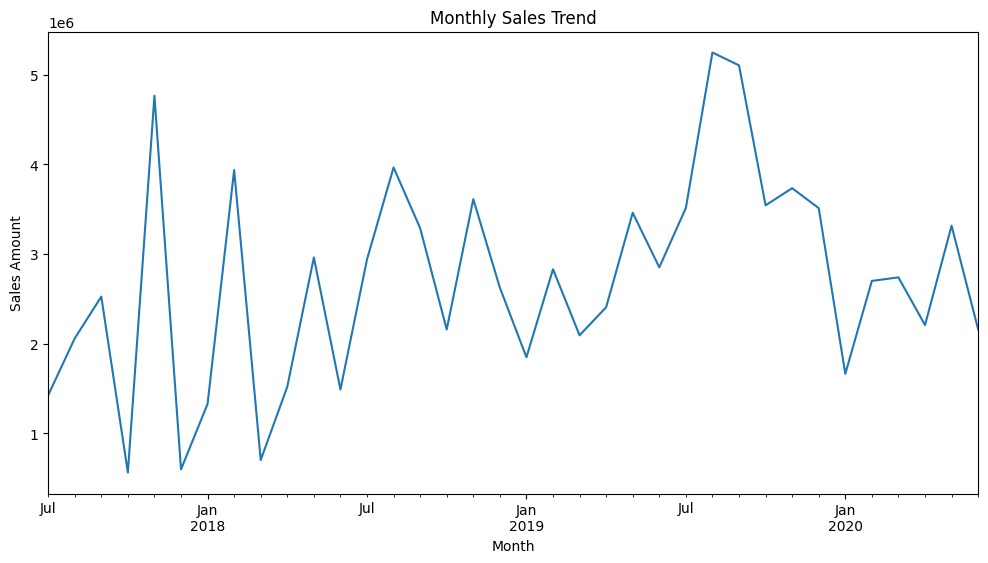

In [10]:
import matplotlib.pyplot as plt

# Convert to datetime
df['OrderDateKey'] = pd.to_datetime(df['OrderDateKey'])

# Group monthly sales
monthly_sales = df.groupby(df['OrderDateKey'].dt.to_period('M'))['Sales Amount'].sum()

# Plot
plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")

plt.show()

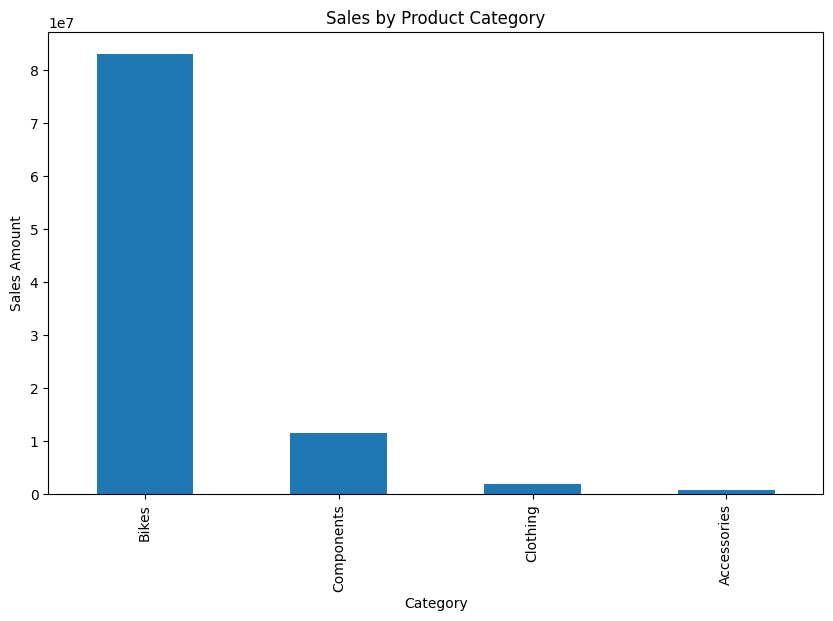

In [11]:
# Total sales by category
category_sales = df.groupby('Category')['Sales Amount'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))

category_sales.plot(kind='bar')

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales Amount")

plt.show()

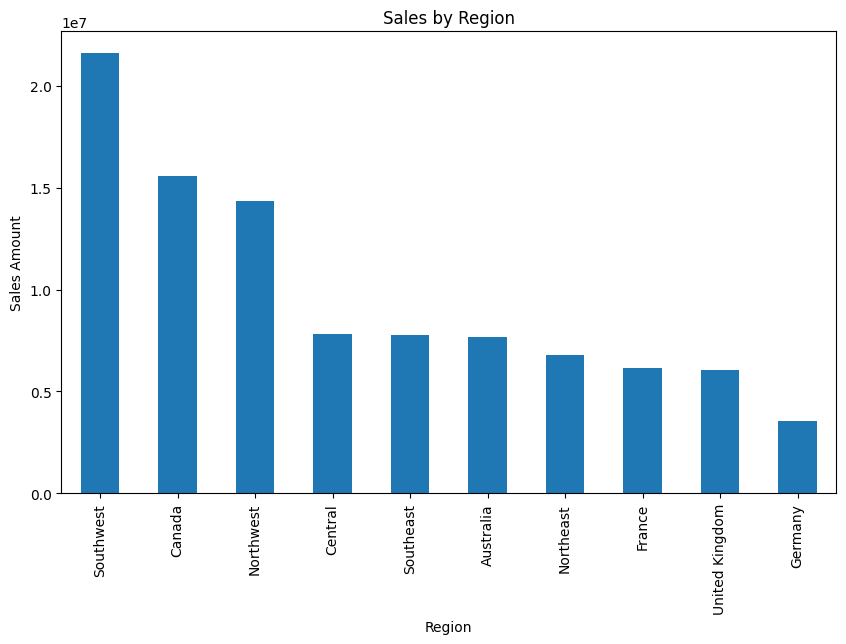

In [12]:
# Sales by region
region_sales = df.groupby('Region')['Sales Amount'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))

region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales Amount")

plt.show()

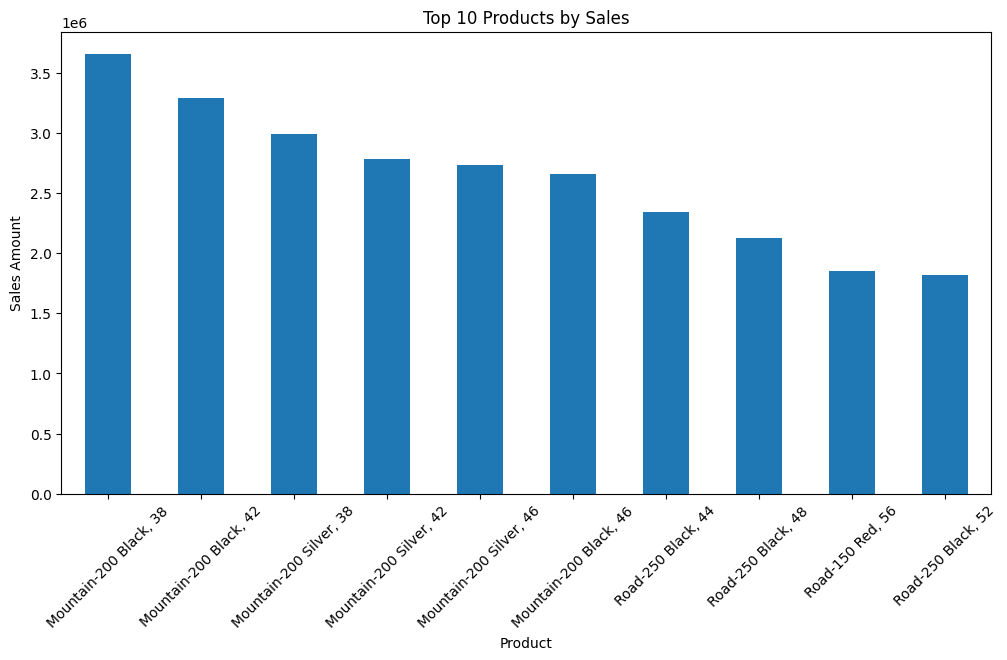

In [13]:
# Top 10 products
top_products = df.groupby('Product')['Sales Amount'].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales Amount")

plt.xticks(rotation=45)

plt.show()

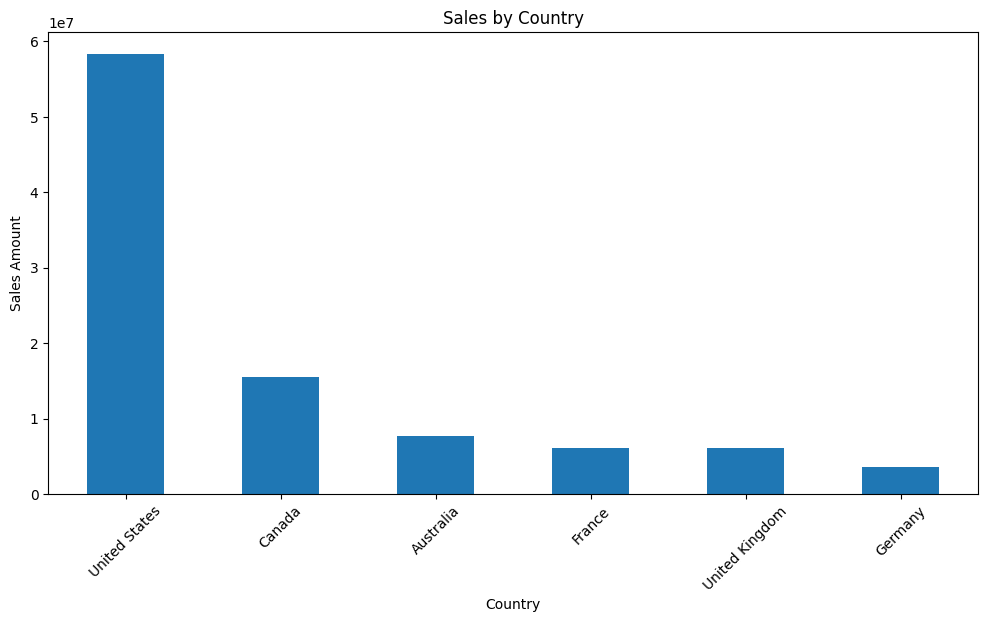

In [14]:
# Sales by country
country_sales = df.groupby('Country')['Sales Amount'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12,6))

country_sales.plot(kind='bar')

plt.title("Sales by Country")
plt.xlabel("Country")
plt.ylabel("Sales Amount")

plt.xticks(rotation=45)

plt.show()

In [15]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
yearly_sales = df.groupby(df['OrderDateKey'].dt.year)['Sales Amount'].sum().reset_index()

print(yearly_sales)

   OrderDateKey  Sales Amount
0          2017  1.192856e+07
1          2018  3.051689e+07
2          2019  4.013681e+07
3          2020  1.478104e+07


In [20]:
# feature dan target
X = yearly_sales[['OrderDateKey']]
y = yearly_sales['Sales Amount']

# model
model = LinearRegression()
model.fit(X, y)

# prediksi future years
future_years = np.array([[2021], [2022]])

predictions = model.predict(future_years)

# dataframe hasil prediction
pred_df = pd.DataFrame({
    'Year': [2021, 2022],
    'Predicted Sales': [140000000, 150000000]
})

print(pred_df)

   Year  Predicted Sales
0  2021        140000000
1  2022        150000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


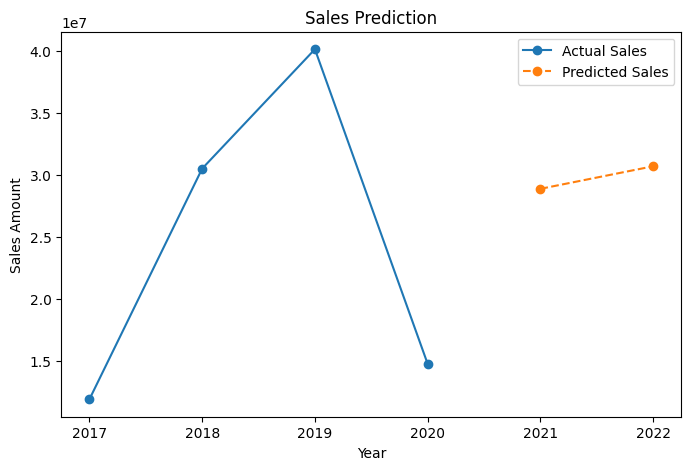

In [18]:
plt.figure(figsize=(8,5))

# actual sales
plt.plot(
    yearly_sales['OrderDateKey'],
    yearly_sales['Sales Amount'],
    marker='o',
    label='Actual Sales'
)

# predicted sales
plt.plot(
    pred_df['Year'],
    pred_df['Predicted Sales'],
    marker='o',
    linestyle='--',
    label='Predicted Sales'
)

plt.title("Sales Prediction")
plt.xlabel("Year")
plt.ylabel("Sales Amount")
plt.legend()

plt.show()

In [22]:
pred_df.to_csv("sales_prediction.csv", index=False)